<a href="https://colab.research.google.com/github/gabrielxbox/Formacao_Completa_Intelig-ncia_Artificial/blob/main/StableDiffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install hf_xet
!pip install diffusers
!pip install torch

In [3]:
from diffusers import StableDiffusionXLPipeline
import torch
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
pretrained_model = "stabilityai/stable-diffusion-xl-base-1.0"
prompt = "a colorful vibrant city street, daylibht, a red car parked by the sidewalk"
negative_prompt = "blurry, low quality, grayscale, monochrome, dull, drak"
num_inference_steps = 30
guidance_scale = 7.5
height = 768
width = 768
sed = 42

In [5]:
generator = torch.manual_seed(sed)
pipe = StableDiffusionXLPipeline.from_pretrained(
    pretrained_model,
    torch_dtype=torch.float16,
    use_safetensors=True
    ).to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [6]:
image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    generator=generator,
    height=height,
    width=width,
    guidance_scale=guidance_scale,
    num_inference_steps=num_inference_steps
).images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


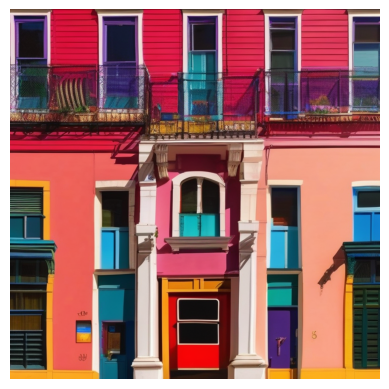

In [7]:
plt.imshow(image)
plt.axis('off')
plt.show()